In [ ]:
inimport numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


pd.options.display.max_columns = 999
pd.options.display.float_format = "{:.2f}".format

In [ ]:
post_implement = pd.read_csv('/content/Assignment - AB Test - Post Implement.xlsx - Sheet1.csv')
ab_test = pd.read_csv('/content/Assignment - spotify_campaign_data.xlsx - spotify_campaign_data.csv')

post_implement

,Date,Total Users
0,1-Mar-26,19304
1,2-Mar-26,16799
2,3-Mar-26,13986
3,4-Mar-26,15981
4,5-Mar-26,18390
5,6-Mar-26,17169
6,7-Mar-26,11660
7,8-Mar-26,21853
8,9-Mar-26,20960
9,10-Mar-26,22583


In [ ]:
post_implement.head()

,Date,Total Users
0,1-Mar-26,19304
1,2-Mar-26,16799
2,3-Mar-26,13986
3,4-Mar-26,15981
4,5-Mar-26,18390


In [ ]:
ab_test.head()

,Group,Engagement,Duration Played,Payment,Subscription
0,Control,"0,6496714153","122,9461844",Yes,Premium
1,Control,"0,5861735699","118,0767531",Yes,Free
2,Control,"0,6647688538","148,5537227",Yes,Premium
3,Control,"0,7523029856","165,9849342",No,Premium
4,Control,"0,5765846625","140,6054083",Yes,Free


In [ ]:
post_implement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         15 non-null     object
 1   Total Users  15 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 372.0+ bytes


In [ ]:
post_implement['Date'] = pd.to_datetime(post_implement['Date'])

/tmp/ipykernel_3560/1484915487.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  post_implement['Date'] = pd.to_datetime(post_implement['Date'])


In [ ]:
ab_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Group            100000 non-null  object
 1   Engagement       100000 non-null  object
 2   Duration Played  100000 non-null  object
 3   Payment          100000 non-null  object
 4   Subscription     100000 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


In [ ]:
ab_test['Engagement'] = ab_test['Engagement'].str.replace(',','.').astype(float)

In [ ]:
ab_test['Duration Played'] = ab_test['Duration Played'].str.replace(',','.').astype(float)

In [ ]:
post_implement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         15 non-null     datetime64[ns]
 1   Total Users  15 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 372.0 bytes


In [ ]:
post_implement.head()

,Date,Total Users
0,2026-03-01,19304
1,2026-03-02,16799
2,2026-03-03,13986
3,2026-03-04,15981
4,2026-03-05,18390


In [ ]:
# Jalankan ini dulu untuk memfilter grup Control
df_control = ab_test[ab_test['Group'] == 'Control']

# Visualisasi 1 - Distribusi Duration Played

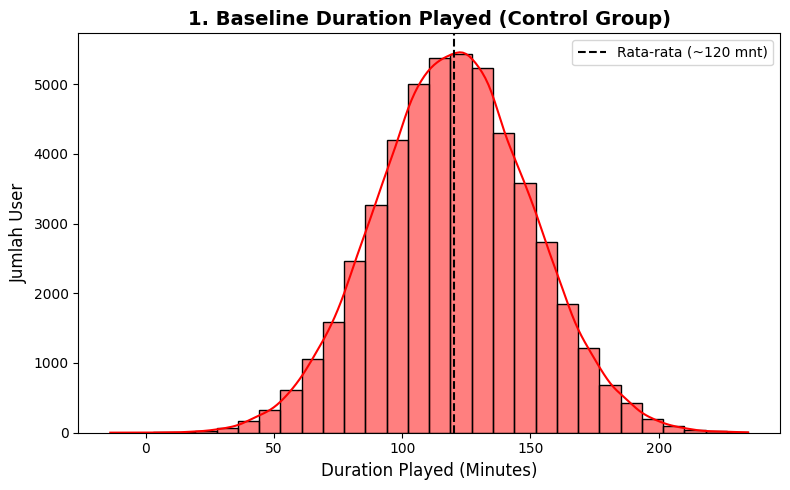

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_control['Duration Played'], kde=True, color='red', bins=30)
plt.axvline(df_control['Duration Played'].mean(), color='black', linestyle='--',
            label=f"Rata-rata (~{df_control['Duration Played'].mean():.0f} mnt)")

plt.title('1. Baseline Duration Played (Control Group)', fontsize=14, fontweight='bold')
plt.xlabel('Duration Played (Minutes)', fontsize=12)
plt.ylabel('Jumlah User', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Visualisasi 2 - Scatter Plot Interaksi & Durasi

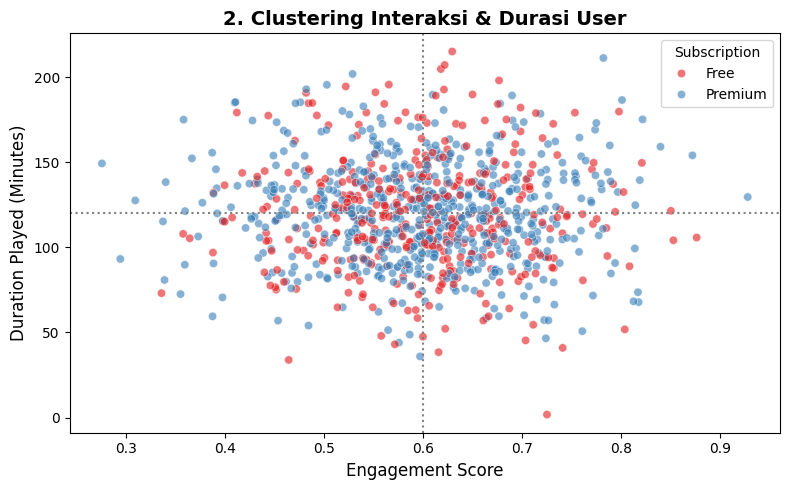

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_control.sample(n=1000, random_state=42),
                x='Engagement', y='Duration Played',
                hue='Subscription', alpha=0.6, palette='Set1')

plt.axhline(120, color='gray', linestyle=':')
plt.axvline(0.6, color='gray', linestyle=':')

plt.title('2. Clustering Interaksi & Durasi User', fontsize=14, fontweight='bold')
plt.xlabel('Engagement Score', fontsize=12)
plt.ylabel('Duration Played (Minutes)', fontsize=12)
plt.tight_layout()
plt.show()

# Visualisasi 3 - Baseline Conversion Rate

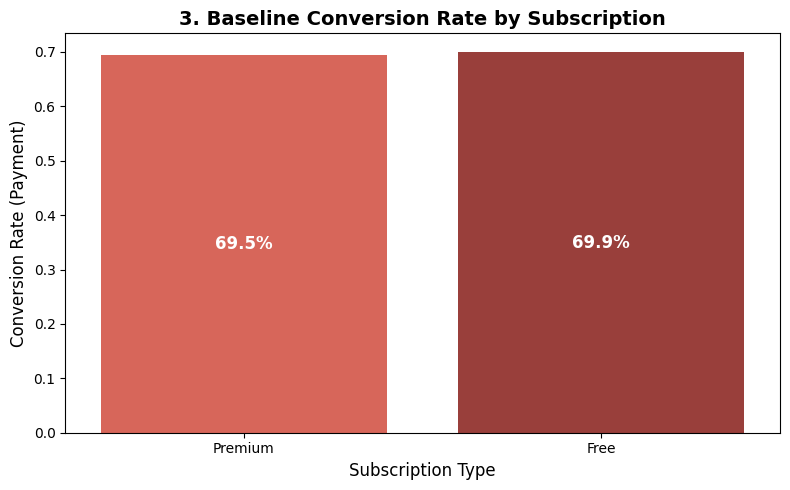

In [ ]:
plt.figure(figsize=(8, 5))

# 1. Buat kolom Payment_Binary secara eksplisit pada df_control
df_control = df_control.copy()
df_control['Payment_Binary'] = df_control['Payment'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

# 2. Render Barplot
ax = sns.barplot(data=df_control, x='Subscription', y='Payment_Binary',
                 hue='Subscription', palette='Reds_d', legend=False, errorbar=None)

plt.title('3. Baseline Conversion Rate by Subscription', fontsize=14, fontweight='bold')
plt.xlabel('Subscription Type', fontsize=12)
plt.ylabel('Conversion Rate (Payment)', fontsize=12)

# 3. Label angka persen di atas bar
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Ubah 'Yes'/'No' menjadi 1 dan 0 pada payment agar bisa dihitung
ab_test['Payment_Binary'] = ab_test['Payment'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

# 2. Pastikan Engagement & Duration Played bertipe numerik
for col in ['Engagement', 'Duration Played']:
    if ab_test[col].dtype == 'object':
        ab_test[col] = ab_test[col].astype(str).str.replace(',', '.').str.strip()
        ab_test[col] = pd.to_numeric(ab_test[col], errors='coerce')

# 3. Hitung Aggregasi Termasuk Conversion Rate
pivot_summary = ab_test.groupby(['Group', 'Subscription']).agg(
    User_Count=('Group', 'count'),
    Avg_Duration=('Duration Played', 'mean'),
    Avg_Engagement=('Engagement', 'mean'),
    Conversion_Rate=('Payment_Binary', 'mean') # Mean di sini = Proporsi Konversi
).reset_index()

# Ubah ke bentuk persen agar lebih mudah dibaca
pivot_summary['Conversion_Rate (%)'] = (pivot_summary['Conversion_Rate'] * 100).round(2)

display(pivot_summary)

,Group,Subscription,User_Count,Avg_Duration,Avg_Engagement,Conversion_Rate,Conversion_Rate (%)
0,Control,Free,20129,119.97,0.60,0.70,69.93
1,Control,Premium,29871,120.14,0.60,0.70,69.53
2,Target,Free,9875,159.60,0.80,0.80,79.92
3,Target,Premium,40125,159.99,0.80,0.80,79.79


In [ ]:
print(ab_test.columns.tolist())
print(ab_test.shape)

['Group', 'Engagement', 'Duration Played', 'Payment', 'Subscription', 'Payment_Binary']
(100000, 6)


In [ ]:
from scipy import stats

# Pakai nama kolom asli langsung, nggak usah rename
c_eng = ab_test[ab_test.Group=='Control']['Engagement']
t_eng = ab_test[ab_test.Group=='Target']['Engagement']
c_dur = ab_test[ab_test.Group=='Control']['Duration Played']
t_dur = ab_test[ab_test.Group=='Target']['Duration Played']

# T-test Engagement & Duration
t1, p1 = stats.ttest_ind(t_eng, c_eng, equal_var=False)
t2, p2 = stats.ttest_ind(t_dur, c_dur, equal_var=False)
print(f"Engagement -> t={t1:.2f}, p={p1:.2e}")
print(f"Duration   -> t={t2:.2f}, p={p2:.2e}")

# Chi-square Payment & Subscription
ct_pay = pd.crosstab(ab_test.Group, ab_test.Payment)
chi2a, pa, _, _ = stats.chi2_contingency(ct_pay)
print(f"Payment      -> chi2={chi2a:.2f}, p={pa:.2e}")

ct_sub = pd.crosstab(ab_test.Group, ab_test.Subscription)
chi2b, pb, _, _ = stats.chi2_contingency(ct_sub)
print(f"Subscription -> chi2={chi2b:.2f}, p={pb:.2e}")

Engagement -> t=315.76, p=0.00e+00
Duration   -> t=209.75, p=0.00e+00
Payment      -> chi2=1357.64, p=3.38e-297
Subscription -> chi2=5005.52, p=0.00e+00


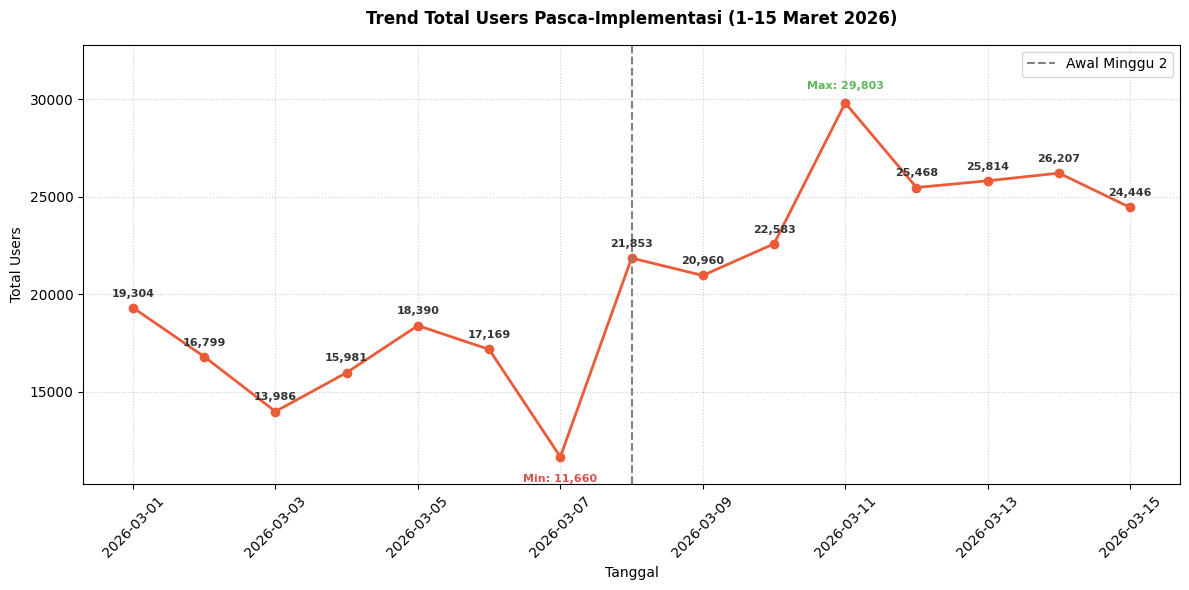

=== Rata-Rata Pengguna Per Minggu ===
Week
Minggu 1 (Adaptasi)        16,184.14
Minggu 2 (Steady State)    24,641.75
Name: Total Users, dtype: object

Pertumbuhan Minggu 2 vs Minggu 1: 52.26%


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Pastikan Date jadi datetime & urut
post_implement['Date'] = pd.to_datetime(post_implement['Date'], format='%d-%b-%y')
post_implement = post_implement.sort_values('Date').reset_index(drop=True)

# Tandain Minggu 1 (adaptasi) vs Minggu 2 (steady state)
post_implement['Week'] = post_implement['Date'].apply(
    lambda x: 'Minggu 1 (Adaptasi)' if x.day <= 7 else 'Minggu 2 (Steady State)'
)

# Deteksi indeks titik ekstrem
min_idx = post_implement['Total Users'].idxmin()
max_idx = post_implement['Total Users'].idxmax()

# 1. Trend chart
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(post_implement['Date'], post_implement['Total Users'], marker='o', color='#EC5B38', linewidth=2)
ax.axvline(post_implement['Date'].iloc[7], color='gray', linestyle='--', label='Awal Minggu 2')

# --- ANNOTATE SEMUA TITIK DENGAN WARNA BEDAKAN KHUSUS EKSTREM ---
for i in range(len(post_implement)):
    val = post_implement['Total Users'].iloc[i]
    date_val = post_implement['Date'].iloc[i]

    # Kondisi warna dan posisi label
    if i == min_idx:
        text_color = '#D9534F'  # Merah menonjol untuk Min
        offset = (0, -18)
        label_text = f"Min: {val:,}"
    elif i == max_idx:
        text_color = '#5CB85C'  # Hijau menonjol untuk Max
        offset = (0, 10)
        label_text = f"Max: {val:,}"
    else:
        text_color = '#333333'  # Abu-abu gelap netral untuk data biasa
        offset = (0, 8)
        label_text = f"{val:,}"

    ax.annotate(
        label_text,
        (date_val, val),
        textcoords="offset points",
        xytext=offset,
        ha='center',
        fontsize=8,
        fontweight='bold',
        color=text_color
    )

plt.title('Trend Total Users Pasca-Implementasi (1-15 Maret 2026)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Tanggal', fontsize=10)
plt.ylabel('Total Users', fontsize=10)
plt.xticks(rotation=45)
plt.ylim(post_implement['Total Users'].min() * 0.88, post_implement['Total Users'].max() * 1.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Rata-rata per minggu + growth %
week_avg = post_implement.groupby('Week')['Total Users'].mean()
print("=== Rata-Rata Pengguna Per Minggu ===")
print(week_avg.map('{:,.2f}'.format))

growth_pct = (week_avg['Minggu 2 (Steady State)'] - week_avg['Minggu 1 (Adaptasi)']) / week_avg['Minggu 1 (Adaptasi)'] * 100
print(f"\nPertumbuhan Minggu 2 vs Minggu 1: {growth_pct:.2f}%")